# Sanity Rollouts: DreamerV3 Cheetah Run

Real-checkpoint sanity checks for the Week 4 DreamerV3 rollout batch. This notebook loads the trained-checkpoint rollouts in `results/rollouts/`, visualizes open-loop L2 drift, and verifies the basic drift properties needed before Month 2 frequency analysis.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np

from utils import REPO_ROOT, ROLLOUT_DIR

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

SEEDS = list(range(20))


In [2]:
def load_rollout(seed):
    path = ROLLOUT_DIR / f'cheetah_v3_seed{seed}.npz'
    data = np.load(path, allow_pickle=True)
    true_obs = data['true_obs']
    imagined_obs = data['imagined_obs']
    l2 = np.linalg.norm(true_obs - imagined_obs, axis=1)
    return {
        'path': path,
        'true_obs': true_obs,
        'imagined_obs': imagined_obs,
        'actions': data['actions'],
        'rewards': data['rewards'],
        'metadata': data['metadata'].item(),
        'l2': l2,
    }

rollouts = {seed: load_rollout(seed) for seed in SEEDS}
l2_stack = np.stack([rollouts[seed]['l2'] for seed in SEEDS])
metadata = rollouts[0]['metadata']

print('Loaded DreamerV3 rollout batch')
print('=' * 42)
print(f"Task: {metadata['task']}")
print(f"Checkpoint: {metadata.get('checkpoint_path', 'results/checkpoints/cheetah_run_500k.pt')}")
print(f"Seeds loaded: {len(rollouts)}")
print(f"true_obs shape: {rollouts[0]['true_obs'].shape}")
print(f"imagined_obs shape: {rollouts[0]['imagined_obs'].shape}")
print(f"actions shape: {rollouts[0]['actions'].shape}")
print(f"rewards shape: {rollouts[0]['rewards'].shape}")


Loaded DreamerV3 rollout batch
Task: dmc_cheetah_run
Checkpoint: results/checkpoints/cheetah_run_500k.pt
Seeds loaded: 20
true_obs shape: (200, 17)
imagined_obs shape: (200, 17)
actions shape: (200, 6)
rewards shape: (200,)


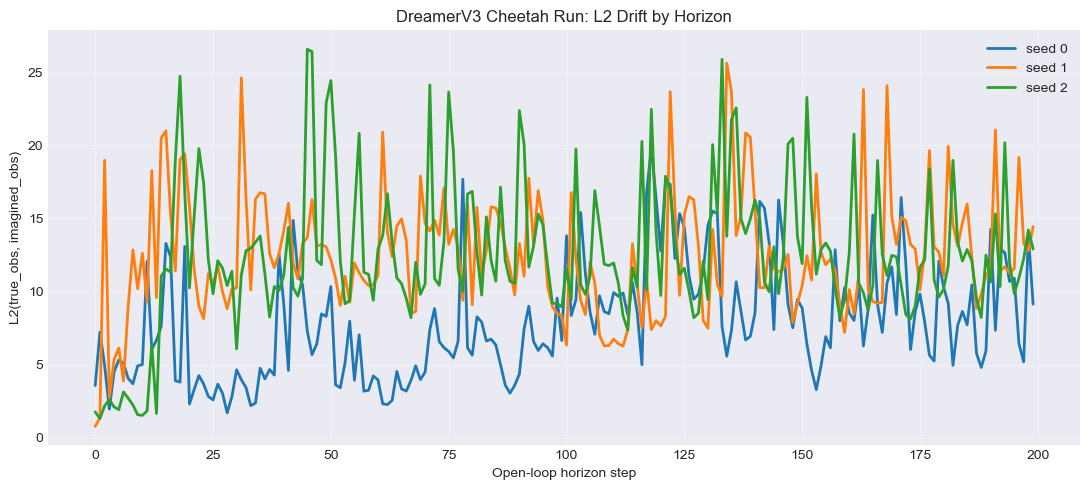

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
for seed in [0, 1, 2]:
    ax.plot(rollouts[seed]['l2'], linewidth=2, label=f'seed {seed}')

ax.set_title('DreamerV3 Cheetah Run: L2 Drift by Horizon')
ax.set_xlabel('Open-loop horizon step')
ax.set_ylabel('L2(true_obs, imagined_obs)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


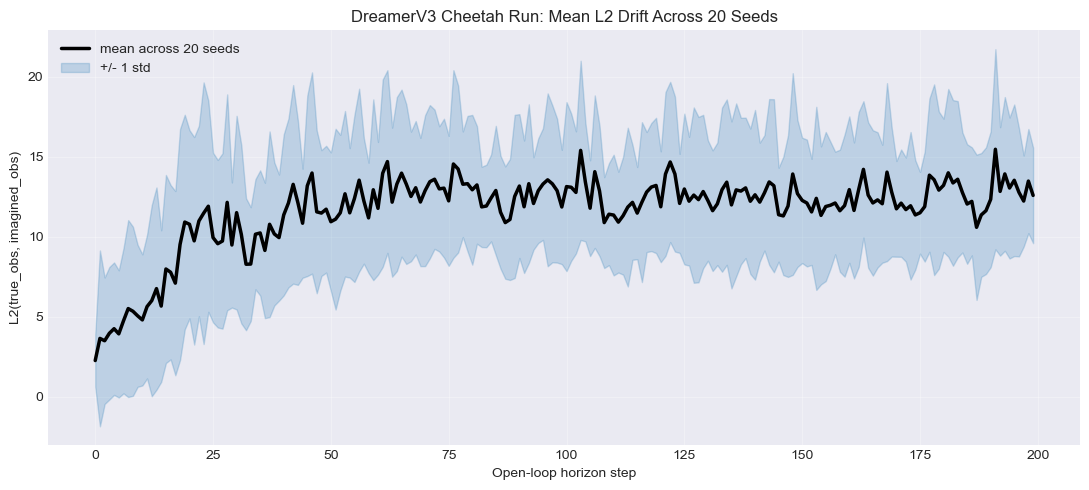

In [4]:
mean_l2 = l2_stack.mean(axis=0)
std_l2 = l2_stack.std(axis=0)
horizon = np.arange(mean_l2.shape[0])

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(horizon, mean_l2, color='black', linewidth=2.5, label='mean across 20 seeds')
ax.fill_between(horizon, mean_l2 - std_l2, mean_l2 + std_l2, color='tab:blue', alpha=0.22, label='+/- 1 std')

ax.set_title('DreamerV3 Cheetah Run: Mean L2 Drift Across 20 Seeds')
ax.set_xlabel('Open-loop horizon step')
ax.set_ylabel('L2(true_obs, imagined_obs)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [5]:
first10 = l2_stack[:, :10].mean(axis=1)
last10 = l2_stack[:, -10:].mean(axis=1)
max_l2 = l2_stack.max(axis=1)

print('Drift property checks')
print('=' * 42)
print(f"All seeds first10 < last10: {bool(np.all(first10 < last10))}")
print(f"All seeds max L2 > 10:       {bool(np.all(max_l2 > 10))}")
print(f"Batch first10 mean:          {first10.mean():.3f}")
print(f"Batch last10 mean:           {last10.mean():.3f}")
print(f"Batch max L2 mean:           {max_l2.mean():.3f}")

assert np.all(first10 < last10), 'Expected first 10 steps L2 < last 10 steps L2 for every seed.'
assert np.all(max_l2 > 10), 'Expected max L2 > 10 for every seed.'


Drift property checks
All seeds first10 < last10: True
All seeds max L2 > 10:       True
Batch first10 mean:          4.214
Batch last10 mean:           13.217
Batch max L2 mean:           27.864


In [6]:
rows = []
for seed in SEEDS:
    l2 = rollouts[seed]['l2']
    rows.append((
        seed,
        float(l2[0]),
        float(l2[100]),
        float(l2[-1]),
        float(l2[:10].mean()),
        float(l2[-10:].mean()),
        float(l2.max()),
        int(l2.argmax()),
    ))

header = (
    'seed', 'l2_step0', 'l2_step100', 'l2_step199',
    'first10_mean', 'last10_mean', 'max_l2', 'max_step'
)
print('Summary statistics table')
print('=' * 108)
print(f"{header[0]:>4} {header[1]:>10} {header[2]:>11} {header[3]:>11} {header[4]:>13} {header[5]:>12} {header[6]:>9} {header[7]:>8}")
print('-' * 108)
for row in rows:
    print(f"{row[0]:4d} {row[1]:10.3f} {row[2]:11.3f} {row[3]:11.3f} {row[4]:13.3f} {row[5]:12.3f} {row[6]:9.3f} {row[7]:8d}")


Summary statistics table
seed   l2_step0  l2_step100  l2_step199  first10_mean  last10_mean    max_l2 max_step
------------------------------------------------------------------------------------------------------------
   0      3.572      13.810       9.142         4.534       10.342    19.816      118
   1      0.792       6.343      14.438         7.132       13.823    25.607      134
   2      1.776      11.582      12.905         2.165       12.861    26.555       45
   3      4.721      22.976      15.572         2.597       16.988    28.646       89
   4      0.944       8.766       6.350         5.243        6.119    31.352       23
   5      1.271      13.444      17.057         3.425       13.794    30.025      143
   6      1.494      15.925      11.921         9.868       13.211    28.283      187
   7      1.500       9.522      14.406         3.271       14.160    27.149      165
   8      0.743      14.141      15.727         9.730       15.209    25.509       97
   9  